# Aftersun: Synthetic Clinic Data Generation

A pipeline that expands 18 real STI testing clinics in Seoul into 500 synthetic clinics, preserving the statistical properties and domain relationships of the original data.
What I focused on: Addressing the small-sample limitation of privacy-sensitive healthcare data.

## 1. Data Loading & Cleaning

Loading 18 real clinics data via `load_and_process_data`, which removes 
example/template rows and non-testing facilities like andrology (23 → 18 clinics).

In [2]:
import pandas as pd
import numpy as np
from data import load_and_process_data

df = load_and_process_data('aftersun_Clinic_Data_Template.xlsx')
print(f"Loaded {df.shape[0]} clinics with {df.shape[1]} attributes")

Loaded 18 clinics with 32 attributes


## 2. Parsing Messy Text Fields

1. Prices in the source data were free-text and inconsistent 
e.g. `'소변 40000원, 피 10000~20000원, HPV 70000원'` (multiple tests, ranges, 
KRW currency).

**What I chose:** For price ranges (10000~20000), I kept both endpoints 
rather than averaging to a midpoint. I tried to avoid creating of values that 
do not exist in the source. The representative price is the mean of all 
extracted values, with min/max preserved separately for range display.

In [3]:
import re

def parse_price(value):
    nums = re.findall(r'\d+', str(value))
    if len(nums) == 0:
        return None, None, None
    int_list = list(map(int, nums))
    return sum(int_list)/len(int_list), min(int_list), max(int_list)

Plus: I manually standardized ambiguous notations
e.g. commas as range VS thousands separator
`1,20000 Won → 10000~20000 Won`
`10,000 Won → 10000 Won`

2. Wait times were similarly free-text (`'2-3일'`, `'당일 결과 확인'`, `'7일'`). 
I parsed these into numeric days, converting "당일" (same-day) to 0.

In [4]:
def parse_result_time(value):
    text = str(value).replace('당일', '0')
    nums = re.findall(r'\d+', text)
    if len(nums) == 0:
        return None
    int_list = list(map(int, nums))
    return sum(int_list) / len(int_list)

result_col = [c for c in df.columns if '소요' in str(c)][0]

df['result_time'] = df[result_col].apply(parse_result_time)

print("Parsed columns created: price_mean, result_time")

Parsed columns created: price_mean, result_time


## 3. Discovering Relationships (EDA)

Before generating, I examined how `clinic_type` drives other attributes. 
Independent generation of each column would produce contradictions 
(e.g. a "public health center" priced at 80,000 KRW). 

Using `groupby`, I found strong type-driven relationships:

- **Price:** public health centers are always free (0 KRW); private clinics 
  are paid, with OB/GYN clinics higher than urology.
- **Wait time:** public health centers are notably slower (~8 days vs ~3-4 days), 
  likely due to external lab processing.
- **Anonymity, weekend hours, online booking:** all vary systematically by clinic type.

These relationships motivated **conditional generation**, generating each 
attribute based on the clinic type, rather than independently.

In [5]:
# Price by clinic type
print("Price by type:")
print(df.groupby('clinic_type')['price_min'].agg(['mean', 'count']))

# Wait time by clinic type  
print("\nWait time by type:")
print(df.groupby('clinic_type')['result_time'].agg(['mean', 'count']))

Price by type:
                       mean  count
clinic_type                       
obstetrics     43333.333333      3
public_health      0.000000      6
urology        28333.333333      6

Wait time by type:
                   mean  count
clinic_type                   
obstetrics     3.055556      3
public_health  8.166667      6
urology        4.266667      5


## 4. Conditional Generation

Each attribute is generated conditionally on clinic type, using one of three 
strategies depending on the nature of the data:

1. **Statistical** (price): normal distribution per type's mean/std, 
   clipped to a floor of 10,000 KRW for paid types. Minimum price is used 
   as the representative value.

2. **Proportional** (anonymity, weekend hours, online booking): sampled by each 
   type's observed category proportions.

3. **Domain-rule-based** (STI count): the source data was recorded inconsistently 
   (counts often left blank while test types were listed in detail). I relied on 
   verified domain knowledge where urology/OB-GYN cover 13 types 
   (12 STIs + HIV), public health centers only cover 3-4.

In [6]:
# Generation parameters derived from the 18 real clinics
type_ratios = df['clinic_type'].value_counts(normalize=True)
type_choices = type_ratios.index.tolist()
type_probs = type_ratios.values

stats = df[df['clinic_type'] != 'public_health'].groupby('clinic_type')['price_min'].agg(['mean', 'std'])
time_stats = df.groupby('clinic_type')['result_time'].agg(['mean', 'std'])

anon_by_type = {t: df[df['clinic_type']==t]['anonymous_testing'].value_counts(normalize=True, dropna=True) for t in df['clinic_type'].unique()}
available_by_type = {t: df[df['clinic_type']==t]['weekend_available'].value_counts(normalize=True, dropna=True) for t in df['clinic_type'].unique()}
online_by_type = {t: df[df['clinic_type']==t]['online_booking'].value_counts(normalize=True, dropna=True) for t in df['clinic_type'].unique()}

In [7]:
#Price

def generate_price_for_type(clinic_type, stats):
    if clinic_type == 'public_health':
        return 0

    mean = stats.loc[clinic_type, 'mean']
    std = stats.loc[clinic_type, 'std']

    price = np.random.normal(mean, std)
    price = max(price, 10000)

    return price

In [8]:
#Anonymity

def generate_anon_for_type(clinic_type, anon_by_type):
    ratios = anon_by_type[clinic_type]
    
    choices = ratios.index.tolist()
    probs = ratios.values

    anon = np.random.choice(choices, p=probs)

    return anon

In [9]:
#STI Count

def generate_sti_count(clinic_type):
    if clinic_type == 'urology' or clinic_type == 'obstetrics':
        return 13

    if clinic_type == 'public_health':
        return np.random.choice([3, 4], p=[0.83, 0.17])

In [10]:
def generate_weekend_available(clinic_type, available_by_type):
    ratios = available_by_type[clinic_type]
    
    choices = ratios.index.tolist()
    probs = ratios.values

    availability = np.random.choice(choices, p = probs)

    return availability

def generate_online_booking(clinic_type, online_by_type):
    ratios = online_by_type[clinic_type]

    choices = ratios.index.tolist()
    probs = ratios.values

    online_booking = np.random.choice(choices, p = probs)

    return online_booking

def generate_result_time(clinic_type, time_stats):
    mean = time_stats.loc[clinic_type, 'mean']
    std = time_stats.loc[clinic_type, 'std']

    waiting_time = np.random.normal(mean, std)
    waiting_time = max(waiting_time, 0)

    return round(waiting_time, 1)

def generate_clinic(type_choices, type_probs, stats, anon_by_type, available_by_type, online_by_type, time_stats):
    clinic_type = np.random.choice(type_choices, p=type_probs)
    price = generate_price_for_type(clinic_type, stats)
    anon = generate_anon_for_type(clinic_type, anon_by_type)
    sti = generate_sti_count(clinic_type)    
    availability = generate_weekend_available(clinic_type, available_by_type)
    online_booking = generate_online_booking(clinic_type, online_by_type)
    waiting_time = generate_result_time(clinic_type, time_stats)

    return {
        'clinic_type': clinic_type,
        'price': round(price),
        'anonymous_testing': anon,
        'sti_count': sti,
        'weekend_available': availability,
        'online_booking': online_booking,
        'waiting_time': waiting_time
    }

## 5. Bulk Generation & Validation

Generated 500 synthetic clinics, then validated that the output preserves 
the original data's distributions and domain relationships.

In [11]:
np.random.seed(42)  # For the same result

clinics = [
    generate_clinic(type_choices, type_probs, stats, anon_by_type,
                    available_by_type, online_by_type, time_stats)
    for _ in range(500)
]

synthetic_df = pd.DataFrame(clinics)
print(f"Generated {synthetic_df.shape[0]} clinics with {synthetic_df.shape[1]} attributes")
synthetic_df.head()

Generated 500 clinics with 7 attributes


,clinic_type,price,anonymous_testing,sti_count,weekend_available,online_booking,waiting_time
0,urology,10000,0.0,13,1.0,0.0,5.0
1,public_health,0,0.5,3,0.0,0.0,6.5
2,urology,17111,0.0,13,1.0,1.0,6.1
3,urology,10000,0.0,13,1.0,1.0,2.9
4,public_health,0,0.5,3,0.0,0.0,9.9


In [12]:
# Validation 1: type distribution matches original
print("Type distribution — Original vs Synthetic")
print("Original:", df['clinic_type'].value_counts(normalize=True).round(3).to_dict())
print("Synthetic:", synthetic_df['clinic_type'].value_counts(normalize=True).round(3).to_dict())

# Validation 2: domain constraint held (public health always free)
print("\nPublic health prices (should all be 0):")
print(synthetic_df[synthetic_df['clinic_type']=='public_health']['price'].value_counts())

# Validation 3: price relationship preserved
print("\nMean price by type -Synthetic:")
print(synthetic_df.groupby('clinic_type')['price'].mean().round(0).to_dict())

Type distribution — Original vs Synthetic
Original: {'urology': 0.444, 'public_health': 0.333, 'obstetrics': 0.222}
Synthetic: {np.str_('urology'): 0.442, np.str_('public_health'): 0.332, np.str_('obstetrics'): 0.226}

Public health prices (should all be 0):
price
0    166
Name: count, dtype: int64

Mean price by type -Synthetic:
{np.str_('obstetrics'): 47364.0, np.str_('public_health'): 0.0, np.str_('urology'): 30903.0}


**Validation results:**
- Type proportions match the source within sampling variance 🙆
- Domain constraint upheld: all 500 public-health clinics are free 🙆🏽‍♀️
- Price ordering preserved (OB-GYN > urology > public health) 🙆🏻‍♂️

The synthetic data reproduces the original's statistical structure and 
domain rules, while expanding the sample 28× (18 → 500).

In [13]:
synthetic_df.to_csv('synthetic_clinics.csv', index=False, encoding='utf-8-sig')
print("Saved to synthetic_clinics.csv")

Saved to synthetic_clinics.csv


In [15]:
print(synthetic_df.shape)
synthetic_df.head()

(500, 7)


,clinic_type,price,anonymous_testing,sti_count,weekend_available,online_booking,waiting_time
0,urology,10000,0.0,13,1.0,0.0,5.0
1,public_health,0,0.5,3,0.0,0.0,6.5
2,urology,17111,0.0,13,1.0,1.0,6.1
3,urology,10000,0.0,13,1.0,1.0,2.9
4,public_health,0,0.5,3,0.0,0.0,9.9


In [20]:
df_encoded = pd.get_dummies(synthetic_df, columns=['clinic_type'])
print(df_encoded.head())

   price  anonymous_testing  sti_count  weekend_available  online_booking  \
0  10000                0.0         13                1.0             0.0   
1      0                0.5          3                0.0             0.0   
2  17111                0.0         13                1.0             1.0   
3  10000                0.0         13                1.0             1.0   
4      0                0.5          3                0.0             0.0   

   waiting_time  clinic_type_obstetrics  clinic_type_public_health  \
0           5.0                   False                      False   
1           6.5                   False                       True   
2           6.1                   False                      False   
3           2.9                   False                      False   
4           9.9                   False                       True   

   clinic_type_urology  
0                 True  
1                False  
2                 True  
3               

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_encoded)
print("normalized shape:", scaled_data.shape)

normalized shape: (500, 9)


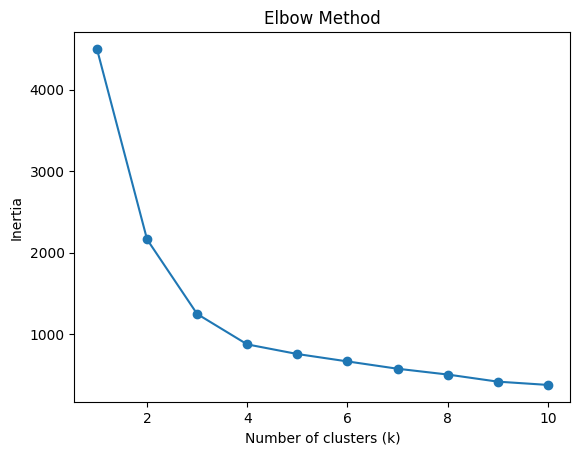

In [26]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_data)
    inertias.append(km.inertia_)

plt.plot(range(1,11), inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [38]:
for k in [3, 4, 5, 6]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = synthetic_df['cluster'] = kmeans.fit_predict(scaled_data)

    temp = synthetic_df.copy()
    temp['cluster'] = labels

    print(f"\n{'='*50}\nk = {k}")
    print(temp.groupby('cluster').mean(numeric_only=True).round(3))
    print("\nGroup num count:", temp['cluster'].value_counts().to_dict())


k = 3
             price  anonymous_testing  sti_count  weekend_available  \
cluster                                                               
0        30902.824              0.412     13.000              0.638   
1            0.000              0.500      3.175              0.000   
2        47363.513              0.000     13.000              1.000   

         online_booking  waiting_time  
cluster                                
0                 0.765         4.114  
1                 0.000         8.287  
2                 1.000         2.912  

Group num count: {0: 221, 1: 166, 2: 113}

k = 4
             price  anonymous_testing  sti_count  weekend_available  \
cluster                                                               
0        30024.592                0.0     13.000              0.662   
1            0.000                0.5      3.175              0.000   
2        47363.513                0.0     13.000              1.000   
3        32157.440              

In [44]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
synthetic_df['cluster'] = kmeans.fit_predict(scaled_data)

cluster_names = {
    0: 'Standard private clinic',
    1: 'Public health center',
    2: 'Premium with high accessibility',
    3: 'Privacy-focused clinic'
}

synthetic_df['segment'] = synthetic_df['cluster'].map(cluster_names)
print(synthetic_df['segment'].value_counts())

segment
Public health center               166
Standard private clinic            130
Premium with high accessibility    113
Privacy-focused clinic              91
Name: count, dtype: int64


In [47]:
p_urology = type_probs[list(type_choices).index('urology')]
p_anon = anon_by_type['urology'][1.0]
print(f"Expected Ratio: {p_urology * p_anon:.3f} → {p_urology * p_anon * 500:.0f}")
print(f"Real Number: 91")

Expected Ratio: 0.178 → 89
Real Number: 91
